In [2]:
import os
import sys

os.environ["PYSPARK_PYTHON"] = sys.executable
os.environ["PYSPARK_DRIVER_PYTHON"] = sys.executable

from pyspark.sql import SparkSession

spark = (
    SparkSession.builder
    .appName("Fraud Detection AI")
    .getOrCreate()
)

# Load dataset
df = (
    spark.read
        .option("header", True)
        .option("inferSchema", True)
        .csv("../data/raw/creditcard.csv")
)

In [3]:
spark

In [4]:
#Print Schema
df.printSchema()

root
 |-- Time: double (nullable = true)
 |-- V1: double (nullable = true)
 |-- V2: double (nullable = true)
 |-- V3: double (nullable = true)
 |-- V4: double (nullable = true)
 |-- V5: double (nullable = true)
 |-- V6: double (nullable = true)
 |-- V7: double (nullable = true)
 |-- V8: double (nullable = true)
 |-- V9: double (nullable = true)
 |-- V10: double (nullable = true)
 |-- V11: double (nullable = true)
 |-- V12: double (nullable = true)
 |-- V13: double (nullable = true)
 |-- V14: double (nullable = true)
 |-- V15: double (nullable = true)
 |-- V16: double (nullable = true)
 |-- V17: double (nullable = true)
 |-- V18: double (nullable = true)
 |-- V19: double (nullable = true)
 |-- V20: double (nullable = true)
 |-- V21: double (nullable = true)
 |-- V22: double (nullable = true)
 |-- V23: double (nullable = true)
 |-- V24: double (nullable = true)
 |-- V25: double (nullable = true)
 |-- V26: double (nullable = true)
 |-- V27: double (nullable = true)
 |-- V28: double (nulla

In [5]:
# Dataset dimensions
num_rows = df.count()
num_columns = len(df.columns)

print(f"Rows: {num_rows:,}")
print(f"Columns: {num_columns}")

Rows: 284,807
Columns: 31


In [6]:
# ==========================
# Missing Values Analysis
# ==========================

from pyspark.sql.functions import col, when, sum

df.select(
    [
        sum(
            when(col(c).isNull(), 1).otherwise(0)
        ).alias(c)
        for c in df.columns
    ]
).show()

+----+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+------+-----+
|Time| V1| V2| V3| V4| V5| V6| V7| V8| V9|V10|V11|V12|V13|V14|V15|V16|V17|V18|V19|V20|V21|V22|V23|V24|V25|V26|V27|V28|Amount|Class|
+----+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+------+-----+
|   0|  0|  0|  0|  0|  0|  0|  0|  0|  0|  0|  0|  0|  0|  0|  0|  0|  0|  0|  0|  0|  0|  0|  0|  0|  0|  0|  0|  0|     0|    0|
+----+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+------+-----+



In [7]:
# ==========================================================
# DISTINCT - Compare Original vs Distinct DataFrame
# ==========================================================

# Remove duplicate rows (Transformation)
df_distinct = df.distinct()

# Compare row counts
original_rows = df.count()
distinct_rows = df_distinct.count()

print(f"Original rows : {original_rows:,}")
print(f"Distinct rows : {distinct_rows:,}")
print(f"Duplicates removed: {original_rows - distinct_rows:,}")

Original rows : 284,807
Distinct rows : 283,726
Duplicates removed: 1,081


In [8]:
# ==========================
# Fraud Distribution
# ==========================

from pyspark.sql import Row
from pyspark.sql.functions import (
    broadcast,
    col,
    round
)

# Create lookup table
class_df = spark.createDataFrame([
    Row(Class=0, Description="Normal Transaction"),
    Row(Class=1, Description="Fraud")
])

# Calculate transactions by class
transactions_df = (
    df
    .groupBy("Class")
    .count()
    .withColumnRenamed("count", "Transactions")
)

# Calculate total number of transactions
total_transactions = df.count()

# Calculate percentage of transactions
transactions_df = (
    transactions_df
    .withColumn(
        "Percentage",
        round(
            col("Transactions") / total_transactions * 100,
            4
        )
    )
)

# Join lookup table with results
result = (
    broadcast(class_df)   
    .join(
        transactions_df,
        on="Class",
        how="inner"
    )
    .orderBy("Class")
)

# Display results
result.show()

+-----+------------------+------------+----------+
|Class|       Description|Transactions|Percentage|
+-----+------------------+------------+----------+
|    0|Normal Transaction|      284315|   99.8273|
|    1|             Fraud|         492|    0.1727|
+-----+------------------+------------+----------+



In [9]:
# ==========================
# Transaction Amount Analysis
# ==========================

from pyspark.sql.functions import (
    avg,
    min,
    max,
    stddev,
    round
)

amount_stats_df = (
    df
    .groupBy("Class")
    .agg(
        round(avg("Amount"), 2).alias("Avg_Amount"),
        round(min("Amount"), 2).alias("Min_Amount"),
        round(max("Amount"), 2).alias("Max_Amount"),
        round(stddev("Amount"), 2).alias("StdDev_Amount")
    )
)

amount_stats_df.show()

+-----+----------+----------+----------+-------------+
|Class|Avg_Amount|Min_Amount|Max_Amount|StdDev_Amount|
+-----+----------+----------+----------+-------------+
|    1|    122.21|       0.0|   2125.87|       256.68|
|    0|     88.29|       0.0|  25691.16|       250.11|
+-----+----------+----------+----------+-------------+



In [10]:
class_df = spark.createDataFrame([
    Row(Class=0, Description="Normal Transaction"),
    Row(Class=1, Description="Fraud")
])


# Join transaction statistics with class descriptions
df_join = (
    broadcast(class_df)
    .join(
        amount_stats_df,
        on="Class",
        how="inner"
    )
    .orderBy("Class")
)

df_join.show()


+-----+------------------+----------+----------+----------+-------------+
|Class|       Description|Avg_Amount|Min_Amount|Max_Amount|StdDev_Amount|
+-----+------------------+----------+----------+----------+-------------+
|    0|Normal Transaction|     88.29|       0.0|  25691.16|       250.11|
|    1|             Fraud|    122.21|       0.0|   2125.87|       256.68|
+-----+------------------+----------+----------+----------+-------------+



In [11]:
# ==========================
# Time Analysis
# ==========================

#First and last timestamps in the dataset

time_stats_df = df.agg(
    min("Time").alias("First_Timestamp"),
    max("Time").alias("Last_Timestamp")
)

time_stats_df.show()

+---------------+--------------+
|First_Timestamp|Last_Timestamp|
+---------------+--------------+
|            0.0|      172792.0|
+---------------+--------------+



In [12]:
from pyspark.sql.functions import col, round

time_stats_df = (
    time_stats_df
    .withColumn(
        "Duration_Days",
        round(
            (col("Last_Timestamp") - col("First_Timestamp")) / (24 * 60 * 60),
            2
        )
    )
)

time_stats_df.show()

+---------------+--------------+-------------+
|First_Timestamp|Last_Timestamp|Duration_Days|
+---------------+--------------+-------------+
|            0.0|      172792.0|          2.0|
+---------------+--------------+-------------+



In [13]:
from pyspark.sql.functions import col, floor

day_df = (
    df.withColumn(
        "Day", 
        floor(col("Time") / (24 * 60 * 60))
    )
)

In [14]:
transactions_per_day_df = (
    day_df
    .groupBy("Day") 
    .count()
    .orderBy("Day")
)

transactions_per_day_df.show()

+---+------+
|Day| count|
+---+------+
|  0|144786|
|  1|140021|
+---+------+



Observation:
The dataset spans approximately two days of transactions. The number of transactions is relatively balanced between both days, with no significant temporal imbalance observed.

In [15]:
# ==========================
# Amount Distribution
# ==========================



df.select("Amount").describe().show()

+-------+-----------------+
|summary|           Amount|
+-------+-----------------+
|  count|           284807|
|   mean|88.34961925093017|
| stddev|250.1201092401885|
|    min|              0.0|
|    max|         25691.16|
+-------+-----------------+



The standard deviation is high relative to the mean, suggesting that the observations are widely spread around the mean and that the variable exhibits considerable variability.

Observation: The Amount feature shows a highly dispersed distribution. While the average transaction amount is approximately €88, the maximum exceeds €25,000, suggesting the presence of significant outliers and a right-skewed distribution.

In [16]:
amount_percentiles = df.approxQuantile("Amount", [0.25, 0.5, 0.75], 0.01)

print(f"25th Percentile: {amount_percentiles[0]:,.2f}")
print(f"50th Percentile (Median): {amount_percentiles[1]:,.2f}")
print(f"75th Percentile: {amount_percentiles[2]:,.2f}") 

25th Percentile: 5.39
50th Percentile (Median): 21.15
75th Percentile: 74.95


In [17]:
amount_pd = (
    df
    .select("Amount")
    .toPandas()
)

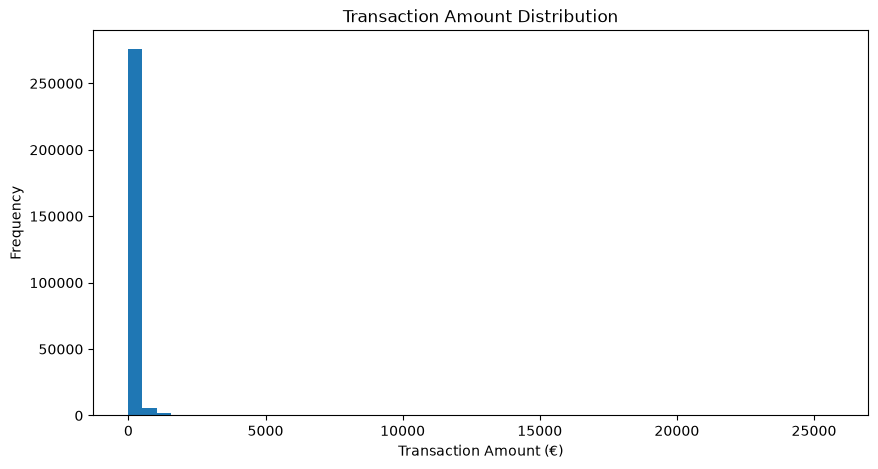

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.hist(
    amount_pd["Amount"],
    bins=50
)

plt.title("Transaction Amount Distribution")
plt.xlabel("Transaction Amount (€)")
plt.ylabel("Frequency")

plt.show()

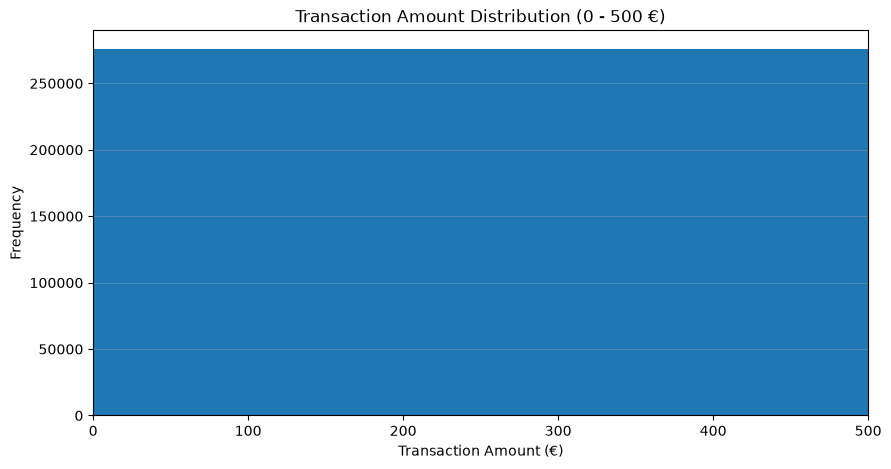

In [19]:
# ==========================
# Amount Distribution (0 - 500 €)
# ==========================

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.hist(
    amount_pd["Amount"],
    bins=50
)

plt.xlim(0, 500)

plt.title("Transaction Amount Distribution (0 - 500 €)")
plt.xlabel("Transaction Amount (€)")
plt.ylabel("Frequency")

plt.grid(axis="y", alpha=0.3)

plt.show()

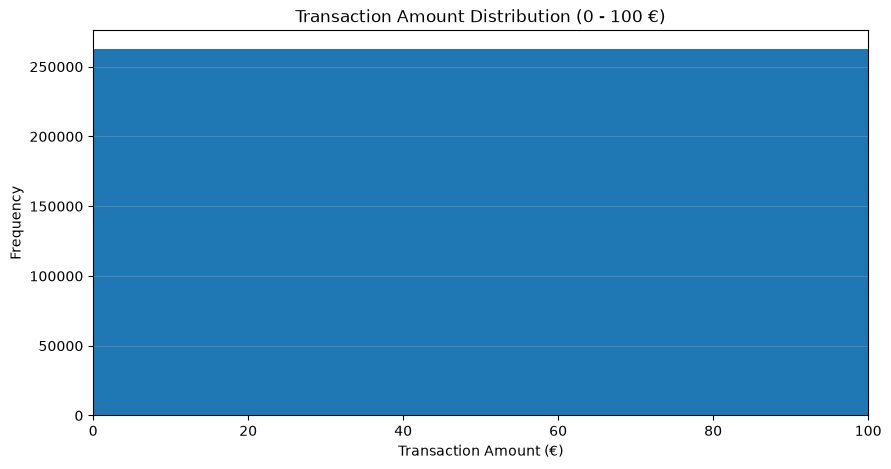

In [20]:
plt.figure(figsize=(10,5))

plt.hist(
    amount_pd["Amount"],
    bins=100
)

plt.xlim(0, 100)

plt.title("Transaction Amount Distribution (0 - 100 €)")
plt.xlabel("Transaction Amount (€)")
plt.ylabel("Frequency")

plt.grid(axis="y", alpha=0.3)

plt.show()

In [21]:
amount_pd["Amount"].describe()


count    284807.000000
mean         88.349619
std         250.120109
min           0.000000
25%           5.600000
50%          22.000000
75%          77.165000
max       25691.160000
Name: Amount, dtype: float64

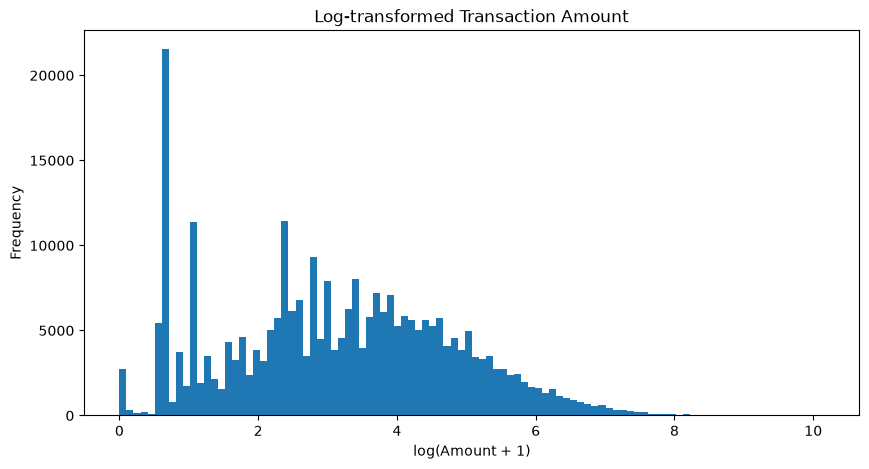

In [22]:
from pyspark.sql.functions import log1p

import numpy as np

amount_pd["Amount_Log"] = np.log1p(amount_pd["Amount"])


plt.figure(figsize=(10,5))

plt.hist(
    amount_pd["Amount_Log"],
    bins=100
)

plt.title("Log-transformed Transaction Amount")
plt.xlabel("log(Amount + 1)")
plt.ylabel("Frequency")

plt.show()

Observation: After applying a logarithmic transformation, the transaction amount distribution becomes much easier to visualize. Most transactions are concentrated at low amounts, while a long right tail confirms the presence of relatively few high-value transactions. Several peaks are visible, suggesting that certain transaction amounts (e.g., €1, €10, €20, €50) occur much more frequently than others.

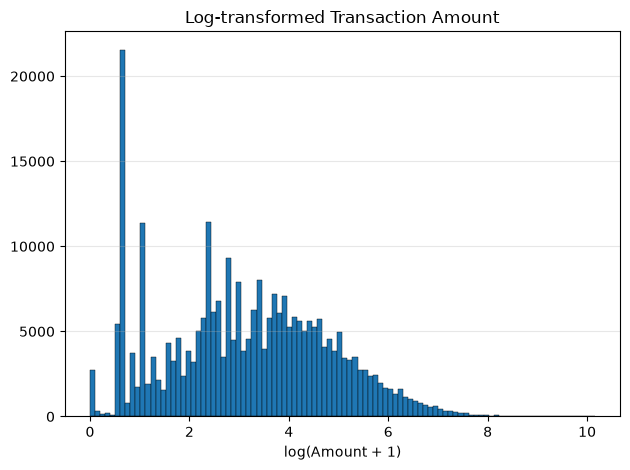

In [23]:
plt.hist(
    amount_pd["Amount_Log"],
    bins=100,
    edgecolor="black",
    linewidth=0.3
)

plt.title("Log-transformed Transaction Amount")
plt.xlabel("log(Amount + 1)")

plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

In [24]:
# ==========================
# Amount Analysis by Class
# ==========================

from pyspark.sql.functions import avg, min, max, stddev

amount_by_class_df = (
    df
    .groupBy("Class")
    .agg(
        avg("Amount").alias("Avg_Amount"),
        min("Amount").alias("Min_Amount"),
        max("Amount").alias("Max_Amount"),
        stddev("Amount").alias("StdDev_Amount")
    )
    .orderBy("Class")
)

amount_by_class_df.show()

+-----+------------------+----------+----------+------------------+
|Class|        Avg_Amount|Min_Amount|Max_Amount|     StdDev_Amount|
+-----+------------------+----------+----------+------------------+
|    0| 88.29102242231212|       0.0|  25691.16|250.10509222589246|
|    1|122.21132113821136|       0.0|   2125.87|256.68328829771207|
+-----+------------------+----------+----------+------------------+



Observation: Fraudulent transactions have a higher average amount (€122.21) than normal transactions (€88.29). However, the substantial overlap in the distributions means that transaction amount alone is unlikely to be sufficient to distinguish fraudulent transactions.

In [25]:
from pyspark.sql.functions import col

normal_percentiles = (
    df
    .filter(col("Class") == 0)
    .approxQuantile("Amount", [0.25, 0.5, 0.75], 0.01)
)

fraud_percentiles = (
    df
    .filter(col("Class") == 1)
    .approxQuantile("Amount", [0.25, 0.5, 0.75], 0.01)
)

In [26]:
print("Normal transactions:", normal_percentiles)
print("Fraud transactions:", fraud_percentiles)

Normal transactions: [5.49, 21.43, 74.95]
Fraud transactions: [1.0, 9.21, 104.81]


Observation:
Although fraudulent transactions have a higher mean amount (€122.21 vs €88.29), their median amount is substantially lower (€9.21 vs €21.43). The 75th percentile, however, is higher for fraudulent transactions (€104.81 vs €74.95). This suggests that fraudulent transactions have a more dispersed distribution, with many low-value transactions but also a relatively heavier upper tail.

In [27]:
# ==========================
# Amount Distribution by Class
# ==========================

amount_class_pd = (
    df
    .select("Amount", "Class")
    .toPandas()
)

<Figure size 800x500 with 0 Axes>

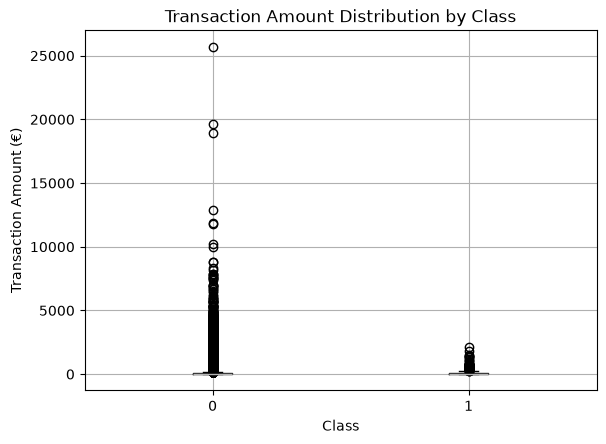

In [28]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

amount_class_pd.boxplot(
    column="Amount",
    by="Class"
)

plt.title("Transaction Amount Distribution by Class")
plt.suptitle("")
plt.xlabel("Class")
plt.ylabel("Transaction Amount (€)")

plt.show()

<Figure size 800x500 with 0 Axes>

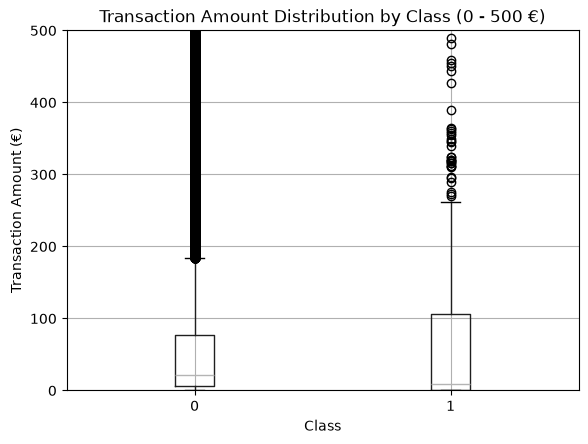

In [29]:
# ==========================
# Amount Distribution by Class (0 - 500 €)
# ==========================

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

amount_class_pd.boxplot(
    column="Amount",
    by="Class"
)

plt.ylim(0, 500)

plt.title("Transaction Amount Distribution by Class (0 - 500 €)")
plt.suptitle("")
plt.xlabel("Class")
plt.ylabel("Transaction Amount (€)")

plt.show()

Observation:
The boxplot confirms that fraudulent transactions have a lower median amount than normal transactions. However, their upper quartile is higher, indicating a wider upper distribution. Fraudulent transactions therefore tend to include many low-value transactions while also showing a significant number of relatively high-value transactions.

In [30]:
class_distribution_df = (
    df
    .groupBy("Class")
    .count()
    .orderBy("Class")
)

class_distribution_df.show()

+-----+------+
|Class| count|
+-----+------+
|    0|284315|
|    1|   492|
+-----+------+



In [31]:
# ==========================
# Class Distribution
# ==========================

from pyspark.sql.functions import col, round

class_distribution_df = (
    df
    .groupBy("Class")
    .count()
    .withColumnRenamed("count", "Count")
    .withColumn(
        "Percentage",
        round(col("Count") / total_transactions * 100, 4)
    )
    .orderBy("Class")
)

class_distribution_df.show()

+-----+------+----------+
|Class| Count|Percentage|
+-----+------+----------+
|    0|284315|   99.8273|
|    1|   492|    0.1727|
+-----+------+----------+



Observation:
The dataset is highly imbalanced. Normal transactions represent 99.8273% of the observations, while fraudulent transactions account for only 0.1727% (492 transactions). This severe class imbalance must be considered when training and evaluating fraud detection models.

In [32]:
fraud_per_day_df = (
    day_df
    .filter(col("Class") == 1)
    .groupBy("Day")
    .count()
    .orderBy("Day")
)

fraud_per_day_df.show()

+---+-----+
|Day|count|
+---+-----+
|  0|  281|
|  1|  211|
+---+-----+



In [33]:
# ==========================
# Fraud Rate by Day
# ==========================

total_per_day_df = (
    day_df
    .groupBy("Day")
    .count()
    .withColumnRenamed("count", "Total_Transactions")
)

fraud_per_day_df = (
    day_df
    .filter(col("Class") == 1)
    .groupBy("Day")
    .count()
    .withColumnRenamed("count", "Fraud_Transactions")
)

fraud_rate_by_day_df = (
    total_per_day_df
    .join(fraud_per_day_df, on="Day", how="left")
    .withColumn(
        "Fraud_Rate",
        round(
            col("Fraud_Transactions") /
            col("Total_Transactions") * 100,
            4
        )
    )
    .orderBy("Day")
)

fraud_rate_by_day_df.show()

+---+------------------+------------------+----------+
|Day|Total_Transactions|Fraud_Transactions|Fraud_Rate|
+---+------------------+------------------+----------+
|  0|            144786|               281|    0.1941|
|  1|            140021|               211|    0.1507|
+---+------------------+------------------+----------+



Observation:
The observed fraud rate was higher on Day 0 (0.1941%) than on Day 1 (0.1507%). However, since the dataset covers only two days, there is insufficient temporal coverage to conclude that fraud risk systematically varies by day.

In [34]:
hour_df = (
    day_df
    .withColumn(
        "Hour",
        floor(col("Time") / (60 * 60) % 24)
    )
)

hour_df.show()

+----+------------------+-------------------+------------------+-------------------+-------------------+-------------------+--------------------+-------------------+------------------+-------------------+------------------+------------------+-------------------+-------------------+-------------------+-------------------+--------------------+-------------------+-------------------+-------------------+--------------------+-------------------+-------------------+-------------------+-------------------+-------------------+--------------------+-------------------+------+-----+---+----+
|Time|                V1|                 V2|                V3|                 V4|                 V5|                 V6|                  V7|                 V8|                V9|                V10|               V11|               V12|                V13|                V14|                V15|                V16|                 V17|                V18|                V19|                V20|         

In [35]:
fraud_by_hour_df = (
    hour_df
    .filter(col("Class") == 1)
    .groupBy("Hour")
    .count()
    .orderBy("Hour")
)

fraud_by_hour_df.show(24)

+----+-----+
|Hour|count|
+----+-----+
|   0|    6|
|   1|   10|
|   2|   57|
|   3|   17|
|   4|   23|
|   5|   11|
|   6|    9|
|   7|   23|
|   8|    9|
|   9|   16|
|  10|    8|
|  11|   53|
|  12|   17|
|  13|   17|
|  14|   23|
|  15|   26|
|  16|   22|
|  17|   29|
|  18|   33|
|  19|   19|
|  20|   18|
|  21|   16|
|  22|    9|
|  23|   21|
+----+-----+



In [36]:
# ==========================
# Total Transactions by Hour
# ==========================

total_by_hour_df = (
    hour_df
    .groupBy("Hour")
    .count()
    .withColumnRenamed("count", "Total_Transactions")
    .orderBy("Hour")
)

total_by_hour_df.show(24)

+----+------------------+
|Hour|Total_Transactions|
+----+------------------+
|   0|              7695|
|   1|              4220|
|   2|              3328|
|   3|              3492|
|   4|              2209|
|   5|              2990|
|   6|              4101|
|   7|              7243|
|   8|             10276|
|   9|             15838|
|  10|             16598|
|  11|             16856|
|  12|             15420|
|  13|             15365|
|  14|             16570|
|  15|             16461|
|  16|             16453|
|  17|             16166|
|  18|             17039|
|  19|             15649|
|  20|             16756|
|  21|             17703|
|  22|             15441|
|  23|             10938|
+----+------------------+



In [37]:
# ==========================
# Fraud Rate by Hour
# ==========================

from pyspark.sql.functions import col, round

fraud_rate_by_hour_df = (
    total_by_hour_df
    .join(
        fraud_by_hour_df.withColumnRenamed("count", "Fraud_Transactions"),
        on="Hour",
        how="left"
    )
    .withColumn(
        "Fraud_Rate",
        round(
            col("Fraud_Transactions") /
            col("Total_Transactions") * 100,
            4
        )
    )
    .orderBy("Hour")
)

fraud_rate_by_hour_df.show(24)

+----+------------------+------------------+----------+
|Hour|Total_Transactions|Fraud_Transactions|Fraud_Rate|
+----+------------------+------------------+----------+
|   0|              7695|                 6|     0.078|
|   1|              4220|                10|     0.237|
|   2|              3328|                57|    1.7127|
|   3|              3492|                17|    0.4868|
|   4|              2209|                23|    1.0412|
|   5|              2990|                11|    0.3679|
|   6|              4101|                 9|    0.2195|
|   7|              7243|                23|    0.3175|
|   8|             10276|                 9|    0.0876|
|   9|             15838|                16|     0.101|
|  10|             16598|                 8|    0.0482|
|  11|             16856|                53|    0.3144|
|  12|             15420|                17|    0.1102|
|  13|             15365|                17|    0.1106|
|  14|             16570|                23|    

Observation:
Fraud rates vary substantially throughout the day. The highest observed fraud rate occurs at 02:00 (1.7127%), followed by 04:00 (1.0412%). These rates are considerably higher than the overall fraud rate of 0.1727%. However, since the dataset covers only two days, these hourly patterns should be interpreted as observations rather than generalizable temporal trends.

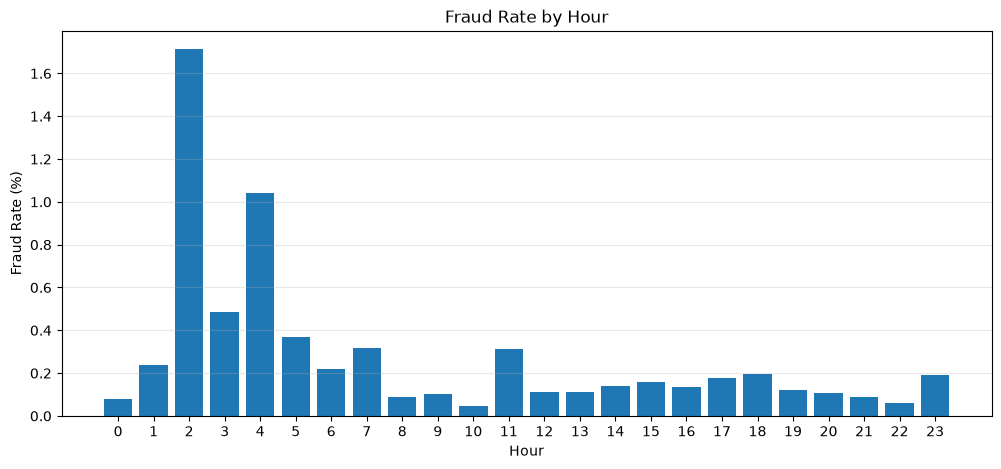

In [38]:
# ==========================
# Fraud Rate by Hour - Visualization
# ==========================

import matplotlib.pyplot as plt

fraud_rate_hour_pd = (
    fraud_rate_by_hour_df
    .toPandas()
)

plt.figure(figsize=(12, 5))

plt.bar(
    fraud_rate_hour_pd["Hour"],
    fraud_rate_hour_pd["Fraud_Rate"]
)

plt.title("Fraud Rate by Hour")
plt.xlabel("Hour")
plt.ylabel("Fraud Rate (%)")
plt.xticks(range(24))

plt.grid(axis="y", alpha=0.3)

plt.show()

In [39]:
# ==========================
# V Features Descriptive Statistics
# ==========================

v_columns = [f"V{i}" for i in range(1, 29)]

df.describe(*v_columns).show()

+-------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+-------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+
|summary|                  V1|                  V2|                  V3|                  V4|                  V5|                  V6|                  V7|                  V8|                  V9|                 V10|                V11|                 V12|                 V13|                 V14|                 V15|                 V16|                 V17|                 V18|                 

In [40]:
# ==========================
# V Features Analysis by Class
# ==========================

from pyspark.sql.functions import avg

v_stats_by_class_df = (
    df
    .groupBy("Class")
    .agg(
        avg("V1").alias("V1_Avg"),
        avg("V2").alias("V2_Avg"),
        avg("V3").alias("V3_Avg")
    )
    .orderBy("Class")
)

v_stats_by_class_df.show()

+-----+--------------------+--------------------+--------------------+
|Class|              V1_Avg|              V2_Avg|              V3_Avg|
+-----+--------------------+--------------------+--------------------+
|    0|0.008257737485563682|-0.00627085741580...|0.012170917031846017|
|    1|  -4.771948441479082|   3.623778101982281| -7.0332810485965584|
+-----+--------------------+--------------------+--------------------+



In [41]:
# ==========================
# V Features Statistics by Class
# ==========================

from pyspark.sql.functions import avg, min, max, stddev

v_stats_by_class_df = (
    df
    .groupBy("Class")
    .agg(
        avg("V1").alias("V1_Avg"),
        min("V1").alias("V1_Min"),
        max("V1").alias("V1_Max"),
        stddev("V1").alias("V1_StdDev"),

        avg("V2").alias("V2_Avg"),
        min("V2").alias("V2_Min"),
        max("V2").alias("V2_Max"),
        stddev("V2").alias("V2_StdDev"),

        avg("V3").alias("V3_Avg"),
        min("V3").alias("V3_Min"),
        max("V3").alias("V3_Max"),
        stddev("V3").alias("V3_StdDev")
    )
    .orderBy("Class")
)

v_stats_by_class_df.show()

+-----+--------------------+----------------+----------------+------------------+--------------------+-----------------+----------------+------------------+--------------------+-----------------+----------------+------------------+
|Class|              V1_Avg|          V1_Min|          V1_Max|         V1_StdDev|              V2_Avg|           V2_Min|          V2_Max|         V2_StdDev|              V3_Avg|           V3_Min|          V3_Max|         V3_StdDev|
+-----+--------------------+----------------+----------------+------------------+--------------------+-----------------+----------------+------------------+--------------------+-----------------+----------------+------------------+
|    0|0.008257737485563682|-56.407509631329|2.45492999121121|1.9298140516500837|-0.00627085741580...|-72.7157275629303|18.9024528401249|1.6361460525689597|0.012170917031846017|-48.3255893623954|9.38255843282114|1.4594290274738584|
|    1|  -4.771948441479082|-30.552380043581|2.13238602134104| 6.7836867

In [42]:
# ==========================
# V Features Analysis by Class
# ==========================

from pyspark.sql.functions import avg

v_stats_by_class_df = (
    df
    .groupBy("Class")
    .agg(
        avg("V1").alias("V1_Avg"),
        avg("V2").alias("V2_Avg"),
        avg("V3").alias("V3_Avg"),
        avg("V4").alias("V4_Avg"),
        avg("V5").alias("V5_Avg"),
        avg("V6").alias("V6_Avg"),
        avg("V7").alias("V7_Avg")
    )
    .orderBy("Class")
)

v_stats_by_class_df.show()

+-----+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+
|Class|              V1_Avg|              V2_Avg|              V3_Avg|              V4_Avg|              V5_Avg|              V6_Avg|              V7_Avg|
+-----+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+
|    0|0.008257737485563682|-0.00627085741580...|0.012170917031846017|-0.00785986782046...|0.005453115888647568|0.002418748436107...|0.009636549929484081|
|    1|  -4.771948441479082|   3.623778101982281| -7.0332810485965584|   4.542029104423093|  -3.151224885936003| -1.3977367105923515|  -5.568731083742741|
+-----+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+



In [43]:
# ==========================
# V Features Analysis by Class
# ==========================

v_stats_by_class_df = (
    df
    .groupBy("Class")
    .agg(
        avg("V8").alias("V8_Avg"),
        avg("V9").alias("V9_Avg"),
        avg("V10").alias("V10_Avg"),
        avg("V11").alias("V11_Avg"),
        avg("V12").alias("V12_Avg"),
        avg("V13").alias("V13_Avg"),
        avg("V14").alias("V14_Avg")
    )
    .orderBy("Class")
)

v_stats_by_class_df.show()

+-----+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+
|Class|              V8_Avg|              V9_Avg|             V10_Avg|             V11_Avg|             V12_Avg|             V13_Avg|             V14_Avg|
+-----+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+
|    0|-9.87471151665286...|0.004466568691335943|0.009823703892289452|-0.00657610422382...|0.010831723172555444|1.891994372611003E-4|0.012064392184377512|
|    1|  0.5706358952962378| -2.5811229217029954|  -5.676882870194369|   3.800172911374609|  -6.259393036190131|-0.10933381708278408|  -6.971722894107603|
+-----+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+



In [44]:
# ==========================
# V Features Analysis by Class
# ==========================

v_stats_by_class_df = (
    df
    .groupBy("Class")
    .agg(
        avg("V15").alias("V15_Avg"),
        avg("V16").alias("V16_Avg"),
        avg("V17").alias("V17_Avg"),
        avg("V18").alias("V18_Avg"),
        avg("V19").alias("V19_Avg"),
        avg("V20").alias("V20_Avg"),
        avg("V21").alias("V21_Avg")
    )
    .orderBy("Class")
)

v_stats_by_class_df.show()

+-----+--------------------+--------------------+-------------------+--------------------+--------------------+--------------------+--------------------+
|Class|             V15_Avg|             V16_Avg|            V17_Avg|             V18_Avg|             V19_Avg|             V20_Avg|             V21_Avg|
+-----+--------------------+--------------------+-------------------+--------------------+--------------------+--------------------+--------------------+
|    0|1.608108734400660...|0.007164072539099496|0.01153506325212937|0.003887180071097961|-0.00117786390907...|-6.44289406888077...|-0.00123484680552...|
|    1|-0.09292874691208501|  -4.139945699092809| -6.665836399449662| -2.2463081339714064|   0.680659303475429|  0.3723193957714718|  0.7135883526687006|
+-----+--------------------+--------------------+-------------------+--------------------+--------------------+--------------------+--------------------+



In [45]:
# ==========================
# V Features Analysis by Class
# ==========================

v_stats_by_class_df = (
    df
    .groupBy("Class")
    .agg(
        avg("V22").alias("V22_Avg"),
        avg("V23").alias("V23_Avg"),
        avg("V24").alias("V24_Avg"),
        avg("V25").alias("V25_Avg"),
        avg("V26").alias("V26_Avg"),
        avg("V27").alias("V27_Avg"),
        avg("V28").alias("V28_Avg")
    )
    .orderBy("Class")
)

v_stats_by_class_df.show()

+-----+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+
|Class|             V22_Avg|             V23_Avg|             V24_Avg|             V25_Avg|             V26_Avg|             V27_Avg|             V28_Avg|
+-----+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+
|    0|-2.43112393403198...|6.975192742794379E-5|1.819253654485378E-4|-7.17262632402463...|-8.93757901491303...|-2.95175413834100...|-1.30940354880169...|
|    1|0.014048882140121212|-0.04030796594836944|-0.10513030543948287| 0.04144888726282705| 0.05164812556245366| 0.17057479224418595| 0.07566729064577461|
+-----+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+



In [46]:
# ==========================
# V Features Average Comparison
# ==========================

from pyspark.sql.functions import avg, col, abs, lit

# V1 to V28
v_columns = [f"V{i}" for i in range(1, 29)]


# Average of V1 to V28 by Class
v_avg_by_class_df = (
    df
    .groupBy("Class")
    .agg(
        *[
            avg(c).alias(f"{c}_Avg")
            for c in v_columns
        ]
    )
)


# Normal transactions - Class 0
normal_avg_df = (
    v_avg_by_class_df
    .filter(col("Class") == 0)
    .select(
        *[
            col(f"{c}_Avg").alias(f"Normal_{c}")
            for c in v_columns
        ]
    )
    .withColumn("Key", lit(1))
)


# Fraud transactions - Class 1
fraud_avg_df = (
    v_avg_by_class_df
    .filter(col("Class") == 1)
    .select(
        *[
            col(f"{c}_Avg").alias(f"Fraud_{c}")
            for c in v_columns
        ]
    )
    .withColumn("Key", lit(1))
)


# Join Normal and Fraud
comparison_df = (
    normal_avg_df
    .join(
        fraud_avg_df,
        on="Key",
        how="inner"
    )
    .drop("Key")
)

comparison_df.show()

+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+-------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+------------------+-----------------+-------------------+-----------------+------------------+-------------------+------------------+------------------+-------------------+------------------+-----------------+------------------+--------------------+------------------+--------------------+------------------+------------------+-------------------+-----------------+------------------+------------------+---------

In [47]:
# ==========================
# Difference Between Classes
# ==========================

difference_df = comparison_df.select(
    *[
        (
            col(f"Fraud_{c}") - col(f"Normal_{c}")
        ).alias(f"{c}_Difference")
        for c in v_columns
    ]
)

difference_df.show()

+-------------------+-----------------+------------------+-----------------+-------------------+-------------------+------------------+------------------+-------------------+------------------+------------------+------------------+--------------------+------------------+--------------------+------------------+-------------------+------------------+------------------+-------------------+-----------------+--------------------+--------------------+-------------------+-------------------+-------------------+-------------------+-------------------+
|      V1_Difference|    V2_Difference|     V3_Difference|    V4_Difference|      V5_Difference|      V6_Difference|     V7_Difference|     V8_Difference|      V9_Difference|    V10_Difference|    V11_Difference|    V12_Difference|      V13_Difference|    V14_Difference|      V15_Difference|    V16_Difference|     V17_Difference|    V18_Difference|    V19_Difference|     V20_Difference|   V21_Difference|      V22_Difference|      V23_Difference| 

In [48]:
# ==========================
# V Feature Differences
# ==========================

from pyspark.sql.functions import col, abs, expr

difference_long_df = (
    difference_df
    .selectExpr(
        "stack(28, " +
        ", ".join([
            f"'{c}', `{c}_Difference`"
            for c in v_columns
        ]) +
        ") as (Variable, Difference)"
    )
    .withColumn(
        "Absolute_Difference",
        abs(col("Difference"))
    )
    .orderBy(
        col("Absolute_Difference").desc()
    )
)

difference_long_df.show(28)

+--------+--------------------+--------------------+
|Variable|          Difference| Absolute_Difference|
+--------+--------------------+--------------------+
|      V3|  -7.045451965628405|   7.045451965628405|
|     V14|  -6.983787286291981|   6.983787286291981|
|     V17| -6.6773714627017915|  6.6773714627017915|
|     V12|  -6.270224759362686|   6.270224759362686|
|     V10|  -5.686706574086658|   5.686706574086658|
|      V7|  -5.578367633672225|   5.578367633672225|
|      V1| -4.7802061789646455|  4.7802061789646455|
|      V4|   4.549888972243558|   4.549888972243558|
|     V16|  -4.147109771631909|   4.147109771631909|
|     V11|  3.8067490155984305|  3.8067490155984305|
|      V2|   3.630048959398088|   3.630048959398088|
|      V5| -3.1566780018246505|  3.1566780018246505|
|      V9| -2.5855894903943315|  2.5855894903943315|
|     V18|  -2.250195314042504|   2.250195314042504|
|      V6| -1.4001554590284588|  1.4001554590284588|
|     V21|   0.714823199474226|   0.7148231994

<Figure size 800x500 with 0 Axes>

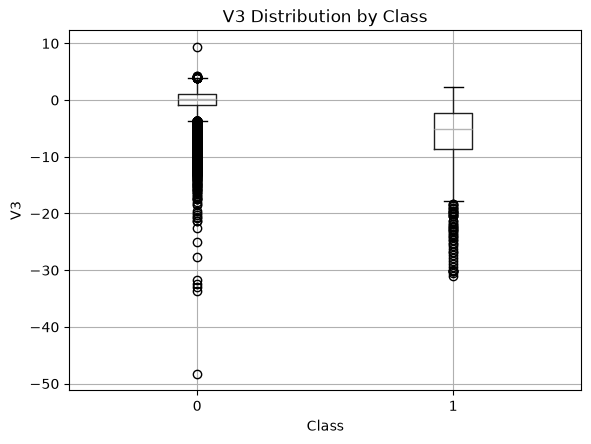

In [49]:
# ==========================
# V3 Distribution by Class
# ==========================

import matplotlib.pyplot as plt

v3_pd = (
    df
    .select("Class", "V3")
    .toPandas()
)

plt.figure(figsize=(8, 5))

v3_pd.boxplot(
    column="V3",
    by="Class"
)

plt.title("V3 Distribution by Class")
plt.suptitle("")
plt.xlabel("Class")
plt.ylabel("V3")

plt.show()

<Figure size 800x500 with 0 Axes>

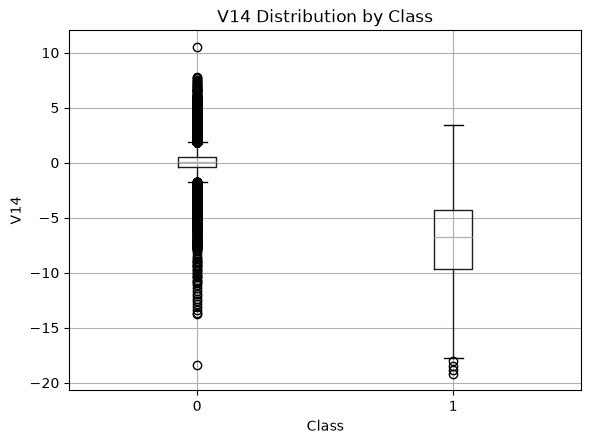

In [50]:
# ==========================
# V14 Distribution by Class
# ==========================

v14_pd = (
    df
    .select("Class", "V14")
    .toPandas()
)

plt.figure(figsize=(8, 5))

v14_pd.boxplot(
    column="V14",
    by="Class"
)

plt.title("V14 Distribution by Class")
plt.suptitle("")
plt.xlabel("Class")
plt.ylabel("V14")

plt.show()

<Figure size 800x500 with 0 Axes>

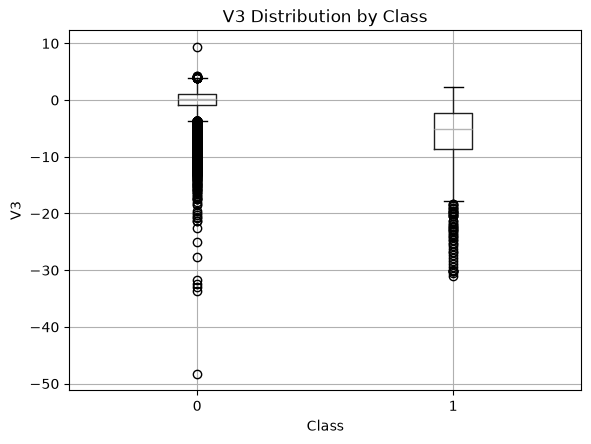

<Figure size 800x500 with 0 Axes>

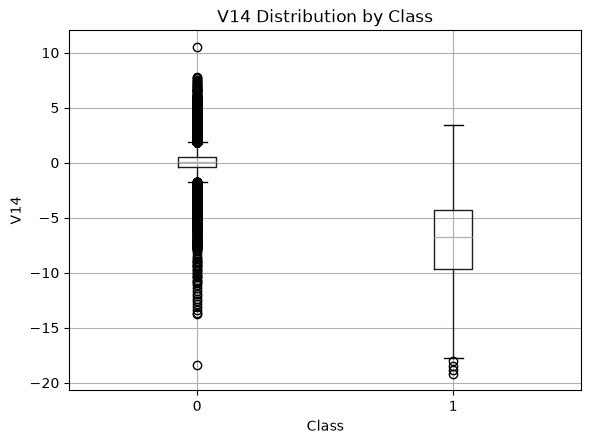

<Figure size 800x500 with 0 Axes>

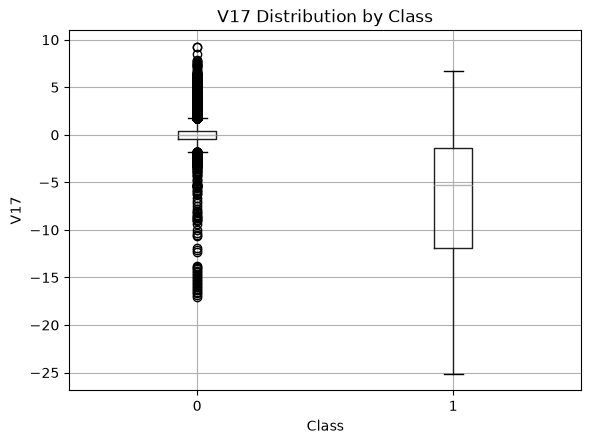

<Figure size 800x500 with 0 Axes>

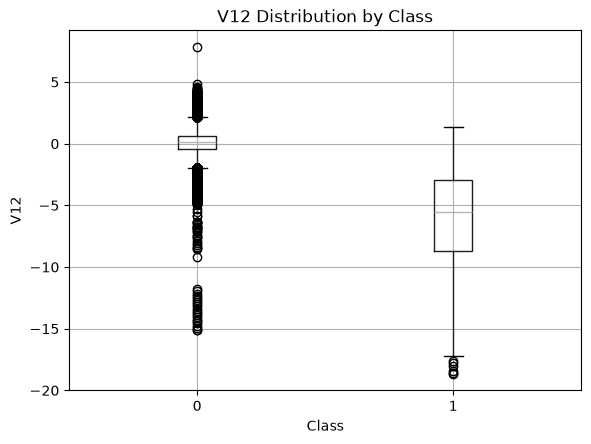

<Figure size 800x500 with 0 Axes>

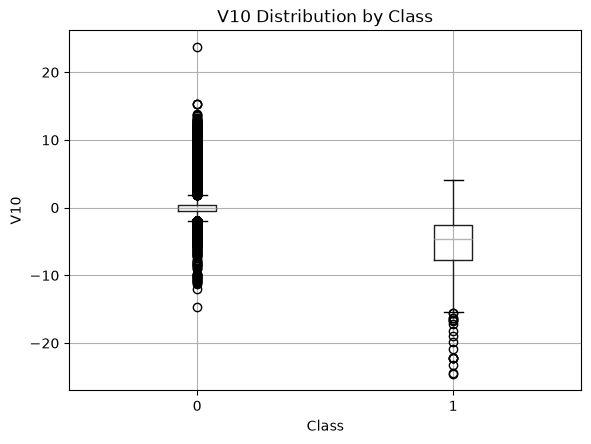

In [51]:
# ==========================
# Top 5 V Features by Class
# ==========================

import matplotlib.pyplot as plt

top_features = ["V3", "V14", "V17", "V12", "V10"]

for feature in top_features:

    feature_pd = (
        df
        .select("Class", feature)
        .toPandas()
    )

    plt.figure(figsize=(8, 5))

    feature_pd.boxplot(
        column=feature,
        by="Class"
    )

    plt.title(f"{feature} Distribution by Class")
    plt.suptitle("")
    plt.xlabel("Class")
    plt.ylabel(feature)

    plt.show()
    

In [52]:
# ==========================
# Prepare Features
# ==========================

from pyspark.ml.feature import VectorAssembler

feature_columns = (
    ["Time", "Amount"] +
    [f"V{i}" for i in range(1, 29)]
)

assembler = VectorAssembler(
    inputCols=feature_columns,
    outputCol="features"
)

ml_df = assembler.transform(df)

In [53]:
from pyspark.sql.functions import col

ml_df = (
    ml_df
    .select(
        "features",
        col("Class").alias("label")
    )
)

In [54]:
# ==========================
# Train / Test Split
# ==========================

train_df, test_df = ml_df.randomSplit(
    [0.8, 0.2],
    seed=42
)

In [55]:
train_df.groupBy("label").count().show()

test_df.groupBy("label").count().show()


+-----+------+
|label| count|
+-----+------+
|    1|   377|
|    0|227475|
+-----+------+

+-----+-----+
|label|count|
+-----+-----+
|    1|  115|
|    0|56840|
+-----+-----+



In [56]:
# ==========================
# Logistic Regression
# ==========================

from pyspark.ml.classification import LogisticRegression

lr = LogisticRegression(
    featuresCol="features",
    labelCol="label"
)

In [57]:
lr_model = lr.fit(train_df)

In [58]:
predictions = lr_model.transform(test_df)

In [59]:
predictions.select(
    "label",
    "prediction",
    "probability"
).show(10, truncate=False)

+-----+----------+------------------------------------------+
|label|prediction|probability                               |
+-----+----------+------------------------------------------+
|0    |0.0       |[0.9998908462849853,1.0915371501474258E-4]|
|0    |0.0       |[0.9995810252909828,4.189747090171947E-4] |
|0    |0.0       |[0.9997399503836681,2.6004961633185886E-4]|
|0    |0.0       |[0.9987941582228144,0.0012058417771856345]|
|0    |0.0       |[0.9999555110065973,4.4488993402702626E-5]|
|0    |0.0       |[0.9991530264624733,8.469735375267184E-4] |
|0    |0.0       |[0.9995849917555306,4.1500824446938367E-4]|
|0    |0.0       |[0.9994701403173161,5.298596826839308E-4] |
|0    |0.0       |[0.9998800751952537,1.1992480474631861E-4]|
|0    |0.0       |[0.9998986610678574,1.0133893214259171E-4]|
+-----+----------+------------------------------------------+
only showing top 10 rows


In [60]:
# ==========================
# Confusion Matrix
# ==========================

predictions.groupBy(
    "label",
    "prediction"
).count().orderBy(
    "label",
    "prediction"
).show()

+-----+----------+-----+
|label|prediction|count|
+-----+----------+-----+
|    0|       0.0|56828|
|    0|       1.0|   12|
|    1|       0.0|   43|
|    1|       1.0|   72|
+-----+----------+-----+



We calculate precision and recall

In [61]:
# ==========================
# F1 Score
# ==========================

from pyspark.ml.evaluation import MulticlassClassificationEvaluator

evaluator = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="f1"
)

f1 = evaluator.evaluate(predictions)

print(f"F1 Score: {f1:.4f}")

F1 Score: 0.9990


In [62]:
evaluator.setMetricName("accuracy")

accuracy = evaluator.evaluate(predictions)

print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.9990


In [63]:
# ==========================
# Confusion Matrix Metrics
# ==========================

tp = predictions.filter(
    (col("label") == 1) & (col("prediction") == 1)
).count()

fp = predictions.filter(
    (col("label") == 0) & (col("prediction") == 1)
).count()

fn = predictions.filter(
    (col("label") == 1) & (col("prediction") == 0)
).count()

tn = predictions.filter(
    (col("label") == 0) & (col("prediction") == 0)
).count()

In [64]:
precision = tp / (tp + fp)

recall = tp / (tp + fn)

f1 = 2 * (precision * recall) / (precision + recall)

accuracy = (tp + tn) / (tp + tn + fp + fn)

In [65]:
print(f"True Positives:  {tp}")
print(f"False Positives: {fp}")
print(f"False Negatives: {fn}")
print(f"True Negatives:  {tn}")

print(f"\nPrecision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")
print(f"Accuracy:  {accuracy:.4f}")

True Positives:  72
False Positives: 12
False Negatives: 43
True Negatives:  56828

Precision: 0.8571
Recall:    0.6261
F1 Score:  0.7236
Accuracy:  0.9990


In [66]:
evaluator = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="f1",
    metricLabel=1.0
)

fraud_f1 = evaluator.evaluate(predictions)

print(f"Fraud F1 Score: {fraud_f1:.4f}")

Fraud F1 Score: 0.9990


In [67]:
from pyspark.ml.functions import vector_to_array
from pyspark.sql.functions import col, when


predictions = predictions.withColumn(
    "fraud_probability",
    vector_to_array(col("probability"))[1]
)

In [68]:
predictions.select(
    "label",
    "fraud_probability",
    "prediction"
).show(10)

+-----+--------------------+----------+
|label|   fraud_probability|prediction|
+-----+--------------------+----------+
|    0|1.091537150147425...|       0.0|
|    0|4.189747090171947E-4|       0.0|
|    0|2.600496163318588...|       0.0|
|    0|0.001205841777185...|       0.0|
|    0|4.448899340270262...|       0.0|
|    0|8.469735375267184E-4|       0.0|
|    0|4.150082444693836...|       0.0|
|    0|5.298596826839308E-4|       0.0|
|    0|1.199248047463186...|       0.0|
|    0|1.013389321425917...|       0.0|
+-----+--------------------+----------+
only showing top 10 rows


In [69]:
# ==========================
# Threshold = 0.3
# ==========================

predictions_threshold = predictions.withColumn(
    "prediction_threshold",
    when(
        col("fraud_probability") >= 0.3,
        1.0
    ).otherwise(0.0)
)

# Confusion Matrix
predictions_threshold.groupBy(
    "label",
    "prediction_threshold"
).count().orderBy(
    "label",
    "prediction_threshold"
).show()

+-----+--------------------+-----+
|label|prediction_threshold|count|
+-----+--------------------+-----+
|    0|                 0.0|56819|
|    0|                 1.0|   21|
|    1|                 0.0|   36|
|    1|                 1.0|   79|
+-----+--------------------+-----+



In [70]:
# ==========================
# Metrics - Threshold 0.3
# ==========================

tp = 79
fp = 21
fn = 36
tn = 56819

precision = tp / (tp + fp)
recall = tp / (tp + fn)
f1 = 2 * (precision * recall) / (precision + recall)
accuracy = (tp + tn) / (tp + tn + fp + fn)

print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")
print(f"Accuracy:  {accuracy:.4f}")

Precision: 0.7900
Recall:    0.6870
F1 Score:  0.7349
Accuracy:  0.9990


In [71]:
# ==========================
# Compare Thresholds
# ==========================

thresholds = [0.5, 0.4, 0.3, 0.2, 0.1]

for threshold in thresholds:

    predictions_threshold = predictions.withColumn(
        "prediction_threshold",
        when(
            col("fraud_probability") >= threshold,
            1.0
        ).otherwise(0.0)
    )

    tp = predictions_threshold.filter(
        (col("label") == 1) &
        (col("prediction_threshold") == 1)
    ).count()

    fp = predictions_threshold.filter(
        (col("label") == 0) &
        (col("prediction_threshold") == 1)
    ).count()

    fn = predictions_threshold.filter(
        (col("label") == 1) &
        (col("prediction_threshold") == 0)
    ).count()

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = (
        2 * precision * recall / (precision + recall)
        if (precision + recall) > 0
        else 0
    )

    print(
        f"Threshold: {threshold:.1f} | "
        f"Precision: {precision:.4f} | "
        f"Recall: {recall:.4f} | "
        f"F1: {f1:.4f}"
    )

Threshold: 0.5 | Precision: 0.8571 | Recall: 0.6261 | F1: 0.7236
Threshold: 0.4 | Precision: 0.8105 | Recall: 0.6696 | F1: 0.7333
Threshold: 0.3 | Precision: 0.7900 | Recall: 0.6870 | F1: 0.7349
Threshold: 0.2 | Precision: 0.8037 | Recall: 0.7478 | F1: 0.7748
Threshold: 0.1 | Precision: 0.7895 | Recall: 0.7826 | F1: 0.7860


In [72]:
# ==========================
# Find Best Threshold
# ==========================

thresholds = [i / 100 for i in range(1, 51)]

results = []

for threshold in thresholds:

    predictions_threshold = predictions.withColumn(
        "prediction_threshold",
        when(
            col("fraud_probability") >= threshold,
            1.0
        ).otherwise(0.0)
    )

    tp = predictions_threshold.filter(
        (col("label") == 1) &
        (col("prediction_threshold") == 1)
    ).count()

    fp = predictions_threshold.filter(
        (col("label") == 0) &
        (col("prediction_threshold") == 1)
    ).count()

    fn = predictions_threshold.filter(
        (col("label") == 1) &
        (col("prediction_threshold") == 0)
    ).count()

    precision = tp / (tp + fp) if tp + fp > 0 else 0
    recall = tp / (tp + fn) if tp + fn > 0 else 0

    f1 = (
        2 * precision * recall / (precision + recall)
        if precision + recall > 0
        else 0
    )

    results.append(
        (threshold, precision, recall, f1)
    )

for result in sorted(results, key=lambda x: x[3], reverse=True)[:10]:
    print(
        f"Threshold: {result[0]:.2f} | "
        f"Precision: {result[1]:.4f} | "
        f"Recall: {result[2]:.4f} | "
        f"F1: {result[3]:.4f}"
    )

Threshold: 0.15 | Precision: 0.8108 | Recall: 0.7826 | F1: 0.7965
Threshold: 0.12 | Precision: 0.8036 | Recall: 0.7826 | F1: 0.7930
Threshold: 0.13 | Precision: 0.8036 | Recall: 0.7826 | F1: 0.7930
Threshold: 0.14 | Precision: 0.8036 | Recall: 0.7826 | F1: 0.7930
Threshold: 0.06 | Precision: 0.7797 | Recall: 0.8000 | F1: 0.7897
Threshold: 0.07 | Precision: 0.7845 | Recall: 0.7913 | F1: 0.7879
Threshold: 0.08 | Precision: 0.7895 | Recall: 0.7826 | F1: 0.7860
Threshold: 0.09 | Precision: 0.7895 | Recall: 0.7826 | F1: 0.7860
Threshold: 0.10 | Precision: 0.7895 | Recall: 0.7826 | F1: 0.7860
Threshold: 0.11 | Precision: 0.7895 | Recall: 0.7826 | F1: 0.7860


In [73]:
from pyspark.ml.classification import RandomForestClassifier

In [74]:
rf = RandomForestClassifier(
    featuresCol="features",
    labelCol="label",
    numTrees=100,
    seed=42
)

In [75]:
rf_model = rf.fit(train_df)

In [76]:
rf_predictions = rf_model.transform(test_df)

In [77]:
rf_predictions.select(
    "label",
    "prediction",
    "probability"
).show(10, truncate=False)

+-----+----------+------------------------------------------+
|label|prediction|probability                               |
+-----+----------+------------------------------------------+
|0    |0.0       |[0.9997385649381633,2.614350618366635E-4] |
|0    |0.0       |[0.9997605913038232,2.3940869617674457E-4]|
|0    |0.0       |[0.9997605913038232,2.3940869617674457E-4]|
|0    |0.0       |[0.9996934197566223,3.065802433777055E-4] |
|0    |0.0       |[0.9997574102594793,2.425897405207135E-4] |
|0    |0.0       |[0.9997367847454154,2.6321525458453777E-4]|
|0    |0.0       |[0.9997605913038232,2.3940869617674457E-4]|
|0    |0.0       |[0.9997605913038232,2.3940869617674457E-4]|
|0    |0.0       |[0.9997438429544158,2.561570455841375E-4] |
|0    |0.0       |[0.9997605913038232,2.3940869617674457E-4]|
+-----+----------+------------------------------------------+
only showing top 10 rows


In [78]:
# ==========================
# Random Forest Confusion Matrix
# ==========================

rf_predictions.groupBy(
    "label",
    "prediction"
).count().orderBy(
    "label",
    "prediction"
).show()

+-----+----------+-----+
|label|prediction|count|
+-----+----------+-----+
|    0|       0.0|56827|
|    0|       1.0|   13|
|    1|       0.0|   26|
|    1|       1.0|   89|
+-----+----------+-----+



In [79]:
# ==========================
# Random Forest Metrics
# ==========================

tp = 89
fp = 13
fn = 26
tn = 56827

precision = tp / (tp + fp)
recall = tp / (tp + fn)
f1 = 2 * (precision * recall) / (precision + recall)
accuracy = (tp + tn) / (tp + tn + fp + fn)

print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")
print(f"Accuracy:  {accuracy:.4f}")

Precision: 0.8725
Recall:    0.7739
F1 Score:  0.8203
Accuracy:  0.9993


In [80]:
# ==========================
# Random Forest Probability
# ==========================

from pyspark.ml.functions import vector_to_array
from pyspark.sql.functions import col, when

rf_predictions = rf_predictions.withColumn(
    "fraud_probability",
    vector_to_array(col("probability"))[1]
)

rf_predictions.select(
    "label",
    "fraud_probability",
    "prediction"
).show(10)

+-----+--------------------+----------+
|label|   fraud_probability|prediction|
+-----+--------------------+----------+
|    0|2.614350618366635E-4|       0.0|
|    0|2.394086961767445...|       0.0|
|    0|2.394086961767445...|       0.0|
|    0|3.065802433777055E-4|       0.0|
|    0|2.425897405207135E-4|       0.0|
|    0|2.632152545845377...|       0.0|
|    0|2.394086961767445...|       0.0|
|    0|2.394086961767445...|       0.0|
|    0|2.561570455841375E-4|       0.0|
|    0|2.394086961767445...|       0.0|
+-----+--------------------+----------+
only showing top 10 rows


In [81]:
# ==========================
# Find Best Random Forest Threshold
# ==========================

thresholds = [i / 100 for i in range(1, 51)]

results = []

for threshold in thresholds:

    rf_threshold = rf_predictions.withColumn(
        "prediction_threshold",
        when(
            col("fraud_probability") >= threshold,
            1.0
        ).otherwise(0.0)
    )

    tp = rf_threshold.filter(
        (col("label") == 1) &
        (col("prediction_threshold") == 1)
    ).count()

    fp = rf_threshold.filter(
        (col("label") == 0) &
        (col("prediction_threshold") == 1)
    ).count()

    fn = rf_threshold.filter(
        (col("label") == 1) &
        (col("prediction_threshold") == 0)
    ).count()

    precision = tp / (tp + fp) if tp + fp > 0 else 0
    recall = tp / (tp + fn) if tp + fn > 0 else 0

    f1 = (
        2 * precision * recall / (precision + recall)
        if precision + recall > 0
        else 0
    )

    results.append(
        (threshold, precision, recall, f1)
    )

# Show top 10 thresholds by F1
for result in sorted(
    results,
    key=lambda x: x[3],
    reverse=True
)[:10]:

    print(
        f"Threshold: {result[0]:.2f} | "
        f"Precision: {result[1]:.4f} | "
        f"Recall: {result[2]:.4f} | "
        f"F1: {result[3]:.4f}"
    )

Threshold: 0.48 | Precision: 0.8738 | Recall: 0.7826 | F1: 0.8257
Threshold: 0.35 | Precision: 0.8585 | Recall: 0.7913 | F1: 0.8235
Threshold: 0.46 | Precision: 0.8654 | Recall: 0.7826 | F1: 0.8219
Threshold: 0.47 | Precision: 0.8654 | Recall: 0.7826 | F1: 0.8219
Threshold: 0.49 | Precision: 0.8725 | Recall: 0.7739 | F1: 0.8203
Threshold: 0.50 | Precision: 0.8725 | Recall: 0.7739 | F1: 0.8203
Threshold: 0.33 | Precision: 0.8505 | Recall: 0.7913 | F1: 0.8198
Threshold: 0.34 | Precision: 0.8505 | Recall: 0.7913 | F1: 0.8198
Threshold: 0.36 | Precision: 0.8571 | Recall: 0.7826 | F1: 0.8182
Threshold: 0.37 | Precision: 0.8571 | Recall: 0.7826 | F1: 0.8182


In [82]:
# ==========================
# Random Forest Feature Importance
# ==========================

importances = rf_model.featureImportances

print(importances)

(30,[0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29],[0.005819338874152358,0.0021084576111043353,0.0026458375621585084,0.014901244740315085,0.03706427062759332,0.051364203830355316,0.01830428376510132,0.014069219744169697,0.09006909248992126,0.005526069741190538,0.049156280468420396,0.07987273788653115,0.05973072134622889,0.1692484838213899,0.0030685930170251743,0.07363904128359744,0.0011941832805414275,0.10851643446776717,0.1469071709219607,0.023821310348663676,0.0032696924249235792,0.0014740279900126352,0.01653864219464696,0.005826589133654682,0.0010061727477435054,0.0014339734002441831,0.0012277424709169903,0.0059632662215239095,0.0049718988000829025,0.0012610187880628095])


In [83]:
feature_columns = (
    ["Time", "Amount"] +
    [f"V{i}" for i in range(1, 29)]
)

In [84]:
feature_importance_list = [
    (feature, importance)
    for feature, importance
    in zip(feature_columns, importances)
]

In [85]:
feature_importance_list = sorted(
    feature_importance_list,
    key=lambda x: x[1],
    reverse=True
)

In [86]:
for feature, importance in feature_importance_list:
    print(f"{feature}: {importance:.4f}")

V12: 0.1692
V17: 0.1469
V16: 0.1085
V7: 0.0901
V10: 0.0799
V14: 0.0736
V11: 0.0597
V4: 0.0514
V9: 0.0492
V3: 0.0371
V18: 0.0238
V5: 0.0183
V21: 0.0165
V2: 0.0149
V6: 0.0141
V26: 0.0060
V22: 0.0058
Time: 0.0058
V8: 0.0055
V27: 0.0050
V19: 0.0033
V13: 0.0031
V1: 0.0026
Amount: 0.0021
V20: 0.0015
V24: 0.0014
V28: 0.0013
V25: 0.0012
V15: 0.0012
V23: 0.0010


In [87]:
# ==========================
# Top 10 Feature Importances
# ==========================

import pandas as pd
import matplotlib.pyplot as plt

importance_pd = pd.DataFrame(
    feature_importance_list[:10],
    columns=["Feature", "Importance"]
)

importance_pd

,Feature,Importance
0,V12,0.169248
1,V17,0.146907
2,V16,0.108516
3,V7,0.090069
4,V10,0.079873
5,V14,0.073639
6,V11,0.059731
7,V4,0.051364
8,V9,0.049156
9,V3,0.037064


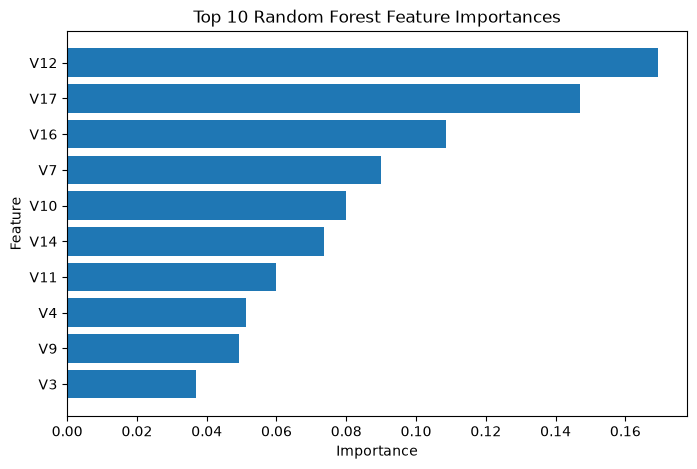

In [88]:
plt.figure(figsize=(8, 5))

plt.barh(
    importance_pd["Feature"],
    importance_pd["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 10 Random Forest Feature Importances")

plt.gca().invert_yaxis()

plt.show()

In [89]:
# ==========================
# Cumulative Feature Importance
# ==========================

cumulative = 0

for feature, importance in feature_importance_list:
    cumulative += importance
    print(
        f"{feature}: "
        f"{importance:.4f} | "
        f"Cumulative: {cumulative:.4f}"
    )

V12: 0.1692 | Cumulative: 0.1692
V17: 0.1469 | Cumulative: 0.3162
V16: 0.1085 | Cumulative: 0.4247
V7: 0.0901 | Cumulative: 0.5147
V10: 0.0799 | Cumulative: 0.5946
V14: 0.0736 | Cumulative: 0.6683
V11: 0.0597 | Cumulative: 0.7280
V4: 0.0514 | Cumulative: 0.7793
V9: 0.0492 | Cumulative: 0.8285
V3: 0.0371 | Cumulative: 0.8656
V18: 0.0238 | Cumulative: 0.8894
V5: 0.0183 | Cumulative: 0.9077
V21: 0.0165 | Cumulative: 0.9242
V2: 0.0149 | Cumulative: 0.9391
V6: 0.0141 | Cumulative: 0.9532
V26: 0.0060 | Cumulative: 0.9592
V22: 0.0058 | Cumulative: 0.9650
Time: 0.0058 | Cumulative: 0.9708
V8: 0.0055 | Cumulative: 0.9763
V27: 0.0050 | Cumulative: 0.9813
V19: 0.0033 | Cumulative: 0.9846
V13: 0.0031 | Cumulative: 0.9876
V1: 0.0026 | Cumulative: 0.9903
Amount: 0.0021 | Cumulative: 0.9924
V20: 0.0015 | Cumulative: 0.9939
V24: 0.0014 | Cumulative: 0.9953
V28: 0.0013 | Cumulative: 0.9966
V25: 0.0012 | Cumulative: 0.9978
V15: 0.0012 | Cumulative: 0.9990
V23: 0.0010 | Cumulative: 1.0000


In [90]:
# ==========================
# Top 10 Features
# ==========================

top_10_features = [
    feature
    for feature, importance in feature_importance_list[:10]
]

print(top_10_features)


['V12', 'V17', 'V16', 'V7', 'V10', 'V14', 'V11', 'V4', 'V9', 'V3']


In [91]:
# ==========================
# Top 10 VectorAssembler
# ==========================

assembler_top10 = VectorAssembler(
    inputCols=top_10_features,
    outputCol="features_top10"
)

ml_top10_df = assembler_top10.transform(df)

In [92]:
ml_top10_df = (
    ml_top10_df
    .select(
        "features_top10",
        col("Class").alias("label")
    )
)

In [93]:
train_top10, test_top10 = ml_top10_df.randomSplit(
    [0.8, 0.2],
    seed=42
)

In [94]:
rf_top10 = RandomForestClassifier(
    featuresCol="features_top10",
    labelCol="label",
    numTrees=100,
    seed=42
)

rf_top10_model = rf_top10.fit(train_top10)

In [95]:
rf_top10_predictions = rf_top10_model.transform(test_top10)

In [96]:
# ==========================
# Top 10 - Confusion Matrix
# ==========================

rf_top10_predictions.groupBy(
    "label",
    "prediction"
).count().orderBy(
    "label",
    "prediction"
).show()

+-----+----------+-----+
|label|prediction|count|
+-----+----------+-----+
|    0|       0.0|56844|
|    0|       1.0|   14|
|    1|       0.0|   20|
|    1|       1.0|   77|
+-----+----------+-----+



In [97]:
# ==========================
# Top 10 - Metrics
# ==========================

tp = 77
fp = 14
fn = 20
tn = 56844

precision = tp / (tp + fp)
recall = tp / (tp + fn)
f1 = 2 * (precision * recall) / (precision + recall)
accuracy = (tp + tn) / (tp + tn + fp + fn)

print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")
print(f"Accuracy:  {accuracy:.4f}")

Precision: 0.8462
Recall:    0.7938
F1 Score:  0.8191
Accuracy:  0.9994


### Feature Selection: Top 10 vs All Features

The Random Forest model using the 10 most important features achieves very similar performance to the model using all 30 features.

- **30 features:** Precision = 87.38%, Recall = 78.26%, F1 = 82.57%
- **Top 10 features:** Precision = 84.62%, Recall = 79.38%, F1 = 81.92%

Reducing the number of features from 30 to 10 results in only a small decrease in F1 score (0.65 percentage points), while Recall slightly improves.

This suggests that the 10 most important features contain most of the information required by the Random Forest model to distinguish fraudulent from normal transactions. However, the model using all features still achieves the best F1 score at the current threshold of 0.5.

In [98]:
# ==========================
# Top 10 - Fraud Probability
# ==========================

from pyspark.ml.functions import vector_to_array
from pyspark.sql.functions import col, when

rf_top10_predictions = rf_top10_predictions.withColumn(
    "fraud_probability",
    vector_to_array(col("probability"))[1]
)

In [99]:
# ==========================
# Top 10 - Best Threshold
# ==========================

thresholds = [i / 100 for i in range(1, 51)]

results_top10 = []

for threshold in thresholds:

    predictions_threshold = rf_top10_predictions.withColumn(
        "prediction_threshold",
        when(
            col("fraud_probability") >= threshold,
            1.0
        ).otherwise(0.0)
    )

    tp = predictions_threshold.filter(
        (col("label") == 1) &
        (col("prediction_threshold") == 1)
    ).count()

    fp = predictions_threshold.filter(
        (col("label") == 0) &
        (col("prediction_threshold") == 1)
    ).count()

    fn = predictions_threshold.filter(
        (col("label") == 1) &
        (col("prediction_threshold") == 0)
    ).count()

    precision = tp / (tp + fp) if tp + fp > 0 else 0
    recall = tp / (tp + fn) if tp + fn > 0 else 0

    f1 = (
        2 * precision * recall / (precision + recall)
        if precision + recall > 0
        else 0
    )

    results_top10.append(
        (threshold, precision, recall, f1)
    )

for result in sorted(
    results_top10,
    key=lambda x: x[3],
    reverse=True
)[:10]:

    print(
        f"Threshold: {result[0]:.2f} | "
        f"Precision: {result[1]:.4f} | "
        f"Recall: {result[2]:.4f} | "
        f"F1: {result[3]:.4f}"
    )

Threshold: 0.35 | Precision: 0.8495 | Recall: 0.8144 | F1: 0.8316
Threshold: 0.36 | Precision: 0.8495 | Recall: 0.8144 | F1: 0.8316
Threshold: 0.37 | Precision: 0.8495 | Recall: 0.8144 | F1: 0.8316
Threshold: 0.38 | Precision: 0.8495 | Recall: 0.8144 | F1: 0.8316
Threshold: 0.39 | Precision: 0.8495 | Recall: 0.8144 | F1: 0.8316
Threshold: 0.40 | Precision: 0.8495 | Recall: 0.8144 | F1: 0.8316
Threshold: 0.41 | Precision: 0.8495 | Recall: 0.8144 | F1: 0.8316
Threshold: 0.42 | Precision: 0.8495 | Recall: 0.8144 | F1: 0.8316
Threshold: 0.43 | Precision: 0.8495 | Recall: 0.8144 | F1: 0.8316
Threshold: 0.44 | Precision: 0.8495 | Recall: 0.8144 | F1: 0.8316


In [100]:
# ==========================
# Model Comparison
# ==========================

model_results = [
    (
        "Logistic Regression",
        30,
        0.15,
        0.8108,
        0.7826,
        0.7965
    ),
    (
        "Random Forest",
        30,
        0.48,
        0.8738,
        0.7826,
        0.8257
    ),
    (
        "Random Forest",
        10,
        0.35,
        0.8495,
        0.8144,
        0.8316
    )
]

columns = [
    "Model",
    "Features",
    "Threshold",
    "Precision",
    "Recall",
    "F1"
]

comparison_df = spark.createDataFrame(
    model_results,
    columns
)

comparison_df.orderBy(
    col("F1").desc()
).show()

+-------------------+--------+---------+---------+------+------+
|              Model|Features|Threshold|Precision|Recall|    F1|
+-------------------+--------+---------+---------+------+------+
|      Random Forest|      10|     0.35|   0.8495|0.8144|0.8316|
|      Random Forest|      30|     0.48|   0.8738|0.7826|0.8257|
|Logistic Regression|      30|     0.15|   0.8108|0.7826|0.7965|
+-------------------+--------+---------+---------+------+------+



### Model Comparison and Final Selection

Three models/configurations were evaluated using Precision, Recall, and F1 Score.

| Model | Features | Threshold | Precision | Recall | F1 |
|---|---:|---:|---:|---:|---:|
| **Random Forest** | **10** | **0.35** | **84.95%** | **81.44%** | **83.16%** |
| Random Forest | 30 | 0.48 | 87.38% | 78.26% | 82.57% |
| Logistic Regression | 30 | 0.15 | 81.08% | 78.26% | 79.65% |

### Final Model

The **Random Forest model using the 10 most important features and a threshold of 0.35** achieved the best overall F1 Score.

- **Precision:** 84.95%
- **Recall:** 81.44%
- **F1 Score:** 83.16%

This model also achieves the highest Recall among the evaluated configurations, meaning it detects a larger proportion of fraudulent transactions.

Reducing the number of features from 30 to 10 did not reduce performance. After optimizing the classification threshold, the 10-feature Random Forest achieved a slightly higher F1 Score than the original 30-feature Random Forest.

Therefore, the **10-feature Random Forest with a 0.35 threshold** is selected as the final model for this project.

In [101]:
# ==========================
# Final Model - Threshold 0.35
# ==========================

final_predictions = rf_top10_predictions.withColumn(
    "final_prediction",
    when(
        col("fraud_probability") >= 0.35,
        1.0
    ).otherwise(0.0)
)

In [102]:
# ==========================
# Final Confusion Matrix
# ==========================

final_predictions.groupBy(
    "label",
    "final_prediction"
).count().orderBy(
    "label",
    "final_prediction"
).show()

+-----+----------------+-----+
|label|final_prediction|count|
+-----+----------------+-----+
|    0|             0.0|56844|
|    0|             1.0|   14|
|    1|             0.0|   18|
|    1|             1.0|   79|
+-----+----------------+-----+



In [103]:
tp = final_predictions.filter(
    (col("label") == 1) &
    (col("final_prediction") == 1)
).count()

fp = final_predictions.filter(
    (col("label") == 0) &
    (col("final_prediction") == 1)
).count()

fn = final_predictions.filter(
    (col("label") == 1) &
    (col("final_prediction") == 0)
).count()

tn = final_predictions.filter(
    (col("label") == 0) &
    (col("final_prediction") == 0)
).count()

precision = tp / (tp + fp)
recall = tp / (tp + fn)
f1 = 2 * precision * recall / (precision + recall)
accuracy = (tp + tn) / (tp + tn + fp + fn)

print(f"TP: {tp}")
print(f"FP: {fp}")
print(f"FN: {fn}")
print(f"TN: {tn}")

print(f"\nPrecision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")
print(f"Accuracy:  {accuracy:.4f}")

TP: 79
FP: 14
FN: 18
TN: 56844

Precision: 0.8495
Recall:    0.8144
F1 Score:  0.8316
Accuracy:  0.9994


In [104]:
# ==========================
# Precision-Recall Curve
# ==========================

import matplotlib.pyplot as plt

pr_pd = (
    rf_top10_predictions
    .select("label", "fraud_probability")
    .toPandas()
)

In [105]:
from sklearn.metrics import precision_recall_curve

precision_values, recall_values, thresholds = precision_recall_curve(
    pr_pd["label"],
    pr_pd["fraud_probability"]
)

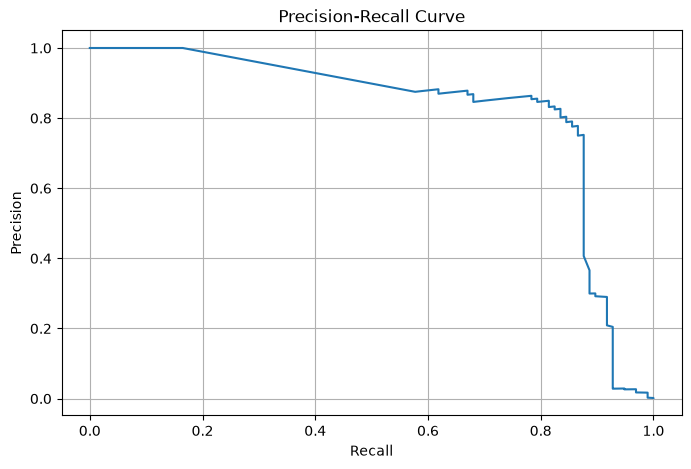

In [106]:
plt.figure(figsize=(8, 5))

plt.plot(
    recall_values,
    precision_values
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")

plt.grid()

plt.show()

In [107]:
# ==========================
# PR-AUC
# ==========================

from sklearn.metrics import auc

pr_auc = auc(
    recall_values,
    precision_values
)

print(f"PR-AUC: {pr_auc:.4f}")

PR-AUC: 0.8222


### Precision-Recall Curve and PR-AUC

Because the dataset is highly imbalanced, with fraudulent transactions representing only a small proportion of the data, the Precision-Recall curve provides a more informative evaluation of the model than accuracy alone.

The final Random Forest model achieves:

- **Precision:** 84.95%
- **Recall:** 81.44%
- **F1 Score:** 83.16%
- **PR-AUC:** 82.22%
- **Selected threshold:** 0.35

The PR-AUC of 0.8222 summarizes the model's Precision-Recall performance across different classification thresholds.

At the selected threshold of 0.35, the model detects 81.44% of fraudulent transactions while maintaining a Precision of 84.95%. This represents a good balance between detecting fraudulent transactions and limiting false positives.

In [109]:
# ==========================
# Save Final Model
# ==========================

model_path = "models/fraud_random_forest_top10"

rf_top10_model.write().overwrite().save(model_path)

print(f"Model saved to: {model_path}")

Py4JJavaError: An error occurred while calling o12949.save.
: java.lang.UnsatisfiedLinkError: 'boolean org.apache.hadoop.io.nativeio.NativeIO$Windows.access0(java.lang.String, int)'
	at org.apache.hadoop.io.nativeio.NativeIO$Windows.access0(Native Method)
	at org.apache.hadoop.io.nativeio.NativeIO$Windows.access(NativeIO.java:817)
	at org.apache.hadoop.fs.FileUtil.canRead(FileUtil.java:1415)
	at org.apache.hadoop.fs.FileUtil.list(FileUtil.java:1620)
	at org.apache.hadoop.fs.RawLocalFileSystem.listStatus(RawLocalFileSystem.java:802)
	at org.apache.hadoop.fs.FileSystem.listStatus(FileSystem.java:2079)
	at org.apache.hadoop.fs.FileSystem.listStatus(FileSystem.java:2123)
	at org.apache.hadoop.fs.ChecksumFileSystem.listStatus(ChecksumFileSystem.java:1020)
	at org.apache.hadoop.fs.FileSystem.listStatus(FileSystem.java:2079)
	at org.apache.hadoop.fs.FileSystem.listStatus(FileSystem.java:2123)
	at org.apache.hadoop.mapreduce.lib.output.FileOutputCommitter.getAllCommittedTaskPaths(Fi